# **Expansión de consultas mediante el algoritmo RM3 con BM25 sobre corpus MEDLINE**

🎯 Objetivos de la práctica

Al finalizar esta práctica, seremos capaces de:

1.   Comprender la motivación y funcionamiento del algoritmo RM3.
2.   Realizar preprocesamiento completo de documentos biomédicos.
3.   Aplicar BM25 como modelo base de recuperación.
4.   Implementar paso a paso el algoritmo RM3 usando Python.
5.   Crear una consulta expandida ponderada usando RM3.
6.   Comparar resultados entre búsqueda sin expansión y búsqueda con RM3.
7.   Analizar los casos donde RM3 mejora o empeora la búsqueda.

La expansión de consultas es muy útil cuando la consulta original:

*   es corta,
*   tiene ambigüedad,
*   no contiene conceptos técnicos usados en el corpus,
*   o cuando el usuario no conoce el vocabulario del dominio (por ejemplo, medicina).

El algoritmo RM3 ayuda a descubrir términos relevantes automáticamente a partir de documentos pseudo-relevantes.

Los **modelos basados en lenguaje (LM)** representan una visión alternativa a los modelos probabilísticos clásicos. En lugar de estimar la probabilidad de que un documento sea relevante para una consulta $P(d|Q)$, estos modelos estiman:



> $P(Q | d)$
>
> Es decir, **la probabilidad de que el documento haya generado la consulta**.

Esta perspectiva cambia radicalmente el enfoque:

| Modelo IR                         | Pregunta que responde                                                                 |
|-----------------------------------|----------------------------------------------------------------------------------------|
| Probabilístico (BM25, BIM)        | ¿Cuál es la probabilidad de que el documento sea relevante para esta consulta?        |
| Modelo basado en lenguaje         | ¿Qué tan probable es que este documento "genere" o "produzca" la consulta?            |

## **SECCIÓN 1: Preparación del entorno**



**Actividad 1.1: Instalación de librerías necesarias e importaciones y configuración inicial:**

In [ ]:
!pip install rank_bm25 nltk pandas 

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from rank_bm25 import BM25Okapi

import numpy as np
import pandas as pd

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

## **SECCIÓN 2: Cargar y preprocesar el corpus MEDLINE**

**Cargar archivo**

El formato corresponde al clásico MEDLINE formato CISI, donde cada documento se identifica así:



> .I $<doc_{id}>$
>
> .W
>
>  $<texto\ libre\ del\ documento>$

y este patrón se repite.

A continuación te proporciono código adaptado que parsea correctamente el archivo y genera una lista docs_raw con un documento por entrada, limpiando los marcadores .I y .W.

In [ ]:
from pathlib import Path
import os

# Obtener el directorio actual y construir la ruta al archivo
currentDirectory = Path().resolve()
file_path = os.path.join(currentDirectory, "med", "MED.ALL")

docs_raw = []
current_doc = []
inside_text = False

with open(file_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()

        # Detecta inicio de nuevo documento
        if line.startswith(".I "):
            # Si ya había texto acumulado, lo guardamos como documento previo
            if current_doc:
                docs_raw.append(" ".join(current_doc).strip())
                current_doc = []
            inside_text = False  # aún no estamos en la parte .W

        # Detecta comienzo del texto
        elif line == ".W":
            inside_text = True

        # Si estamos dentro del texto, acumulamos contenido
        elif inside_text:
            if line != "":
                current_doc.append(line)

    # guardar último documento si quedó en buffer
    if current_doc:
        docs_raw.append(" ".join(current_doc).strip())

print(f"Total de documentos cargados: {len(docs_raw)}")
print("\nPrimer documento:\n", docs_raw[0][:600])

##### **Actividad 2.1: Limpieza y tokenización**

El objetivo del preprocesamiento es normalizar el texto, eliminar ruido, y reducir el vocabulario sin perder información relevante, de forma que el modelo de recuperación trabaje con tokens representativos y consistentes.

A continuación, se detalla cada paso en orden:
1. Conversión a minúsculas (lowercasing)
2. Tokenización (separación de palabras)
3. Eliminación de caracteres no alfabéticos
4. Eliminación de stopwords
5. Stemming (raíces morfológicas)


In [ ]:
def preprocess(text):
    """
        1. Conversión a minúsculas (lowercasing)
        2. Tokenización (separación de palabras)
        3. Eliminación de caracteres no alfabéticos
        4. Eliminación de stopwords
        5. Stemming (raíces morfológicas)
    """
    # 1. Lowercasing
    text = text.lower()
    # 2. Tokenización
    tokens = text.split()
    # 3. Eliminación de caracteres no alfabéticos
    tokens = [t for t in tokens if t.isalpha()]
    # 4. Eliminación de stopwords
    stopwords = nltk.corpus.stopwords.words("english")
    tokens = [t for t in tokens if t not in stopwords]
    # 5. Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    return tokens


test = "Significant correlations were obtained between the maternal and fetal Glucose levels."
print(preprocess(test))

corpus_tokens = [preprocess(doc) for doc in docs_raw]

**Pregunta:** ¿Qué ventajas e inconvenientes tendría usar lematización en textos médicos?

**Respuesta:**
En cuanto a los inconvenientes, uno de ellos es el mayor coste computaciones que supone la lematización, pues requiere de un análisis morfológico. También, los documentos médicos tienen una terminología muy específica, provocando que lematizadores generales no reconozcan los términos adecuadamente. Se necesitaría uno específico al ámbito.

Por otro lado, en relación a las ventajas, la lematización convertiría las palabras a su forma canónica, reduciendo así taambién el vocaulario pero sin perder el significado base de la palabra.


## **SECCIÓN 3: Construir índice BM25**

La clase *BM25Okapi*, incluida en la librería *rank_bm25*, es una implementación en Python del algoritmo BM25 (Best Matching 25), uno de los métodos más utilizados y con mejor rendimiento en sistemas de recuperación de información.

BM25 es un modelo probabilístico que permite calcular un score de relevancia entre una consulta y cada documento de un corpus, basado en:

* La frecuencia de los términos de la consulta dentro del documento

* La longitud del documento (penalizando documentos demasiado largos)

* La importancia global de los términos en la colección (similar a IDF)

Por defecto los valores de $k_{1}​=1.5$ y el de $b=0.75$.

In [ ]:
bm25 = BM25Okapi(corpus_tokens)
print("Índice BM25 construido correctamente.")

## **SECCIÓN 4: Primera búsqueda con la consulta original**

En este paso, vamos a comprobar visualmente que el índice BM25 construido a partir del corpus es capaz de asignar puntuaciones diferenciadas a los documentos ante una consulta de prueba.

La idea es:

1. Definir una consulta sencilla formada por una o varias palabras clave.
2. Obtener los *scores* BM25 para todos los documentos del corpus.
3. Visualizar cómo se distribuyen dichos *scores* mediante un gráfico, para observar:
   - si hay documentos significativamente más relevantes que el resto,
   - si la distribución es uniforme o dispersa,
   - si existen valores atípicos (outliers) que merezcan análisis adicional.

Esto nos permite validar que el índice BM25 está funcionando correctamente antes de continuar con algoritmos más avanzados como RM1 o RM3.

Un ejemplo de consulta podría ser: "*breast cancer treatment*"




In [ ]:
# 1. Definir consulta de prueba
query = input("Introduce tu consulta: ")
q_tokens = preprocess(query)
print("Tokens de la consulta:", q_tokens)

test_scores = bm25.get_scores(q_tokens)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 2. Visualización
plt.figure(figsize=(10, 5))
plt.plot(test_scores, marker="o", linestyle="-", linewidth=1)
plt.title(f"Distribución de scores BM25 para la consulta: {q_tokens}")
plt.xlabel("Índice de documento")
plt.ylabel("Puntuación BM25")
plt.grid(True)
plt.show()

# 3. Mostrar estadísticas descriptivas
print("Estadísticas de scores BM25")
print(f"Score máximo: {np.max(test_scores):.4f}")
print(f"Score mínimo: {np.min(test_scores):.4f}")
print(f"Score medio:  {np.mean(test_scores):.4f}")
print(f"Score mediana: {np.median(test_scores):.4f}")

Con esta visualización deberías observar:

* Una línea (o nube) representando el score de cada documento del corpus.

* Algunos documentos con puntuación claramente superior (los posibles relevantes).

* La mayoría de documentos con score bajo (irrelevantes para esa consulta inicial).

Esto confirma que el índice está funcionando correctamente y permite entender mejor la base del ranking antes de aplicar RM3.

#### **Actividad 4.1: Seleccionar top-k documentos (pseudo-relevantes)**

En algoritmos de expansión de consulta como RM1 y RM3, es necesario estimar un modelo de relevancia a partir de ejemplos de texto que se asume que son relevantes para la consulta, pero **sin intervención humana**.
Para ello, utilizamos los llamados documentos pseudo-relevantes, que corresponden a los primeros $k$ documentos del ranking obtenido con el modelo base (en este caso BM25).

La idea es:

1. **No conocemos** cuáles documentos son realmente relevantes, porque en la mayoría de casos **no disponemos de juicios de relevancia humanos**.

2. Sin embargo, es razonable **asumir** que los documentos mejor posicionados por el modelo base **son buenos candidatos** a contener palabras relacionadas con la intención real del usuario.

3. Por tanto, **seleccionamos los $k$ documentos mejor puntuados** como nuestro conjunto de ejemplos “aproximadamente relevantes”, de donde extraeremos información semántica adicional (términos, probabilidades, coocurrencias, etc.).

Este enfoque se denomina **retroalimentación pseudo-relevante (pseudo-relevance feedback: PRF)** y se basa en el principio de que, aunque algunos de estos documentos pueden no ser relevantes, la mayoría debería aportar vocabulario útil, reduciendo así la necesidad de retroalimentación humana explícita.

In [ ]:
scores = bm25.get_scores(q_tokens)

# Ordenar y obtener top-k documentos
k = 10  # puedes cambiarlo
print("Top-k documentos recuperados:")
ranking = scores.argsort()[::-1][:k]  # top-k documentos
for rank, idx in enumerate(ranking, 1):
    print(f"{rank}. Doc {idx} -> Score: {scores[idx]:.4f}")

## **SECCIÓN 5: Algoritmo RM3**

**5.1 Resumen conceptual**

Aquí vamos a explicar qué hace exactamente RM3, paso por paso, con fórmulas e intuición. En nuestro caso, el modelo base es BM25, pero RM3 se define de forma genérica.


**5.1. Idea general**

El objetivo del algoritmo RM3 es mejorar la consulta original construyendo un **modelo de lenguaje de relevancia, estimado a partir de los documentos top–k recuperados inicialmente** (pseudo–relevancia). Este modelo intenta responder a la pregunta:

> ¿Qué términos caracterizan mejor los documentos que probablemente sean relevantes para la consulta del usuario?

Luego mezclamos ese modelo con la consulta original para crear una consulta expandida.

Para ello, RM3 se basa en dos componentes:

* **El modelo de lenguaje de la consulta original**, denotado como:
$$P_{Q}(w)$$

  que refleja la importancia inicial de los términos proporcionados por el usuario.

* **El modelo de lenguaje de relevancia estimado**, denotado como:
$$P_{RM1}(w)$$

  que se obtiene estadísticamente a partir de los $k$ documentos mejor puntuados.

  Este modelo estima la **probabilidad de que un término $w$** sea característico del conjunto de documentos que consideramos (aproximadamente) relevantes, aunque **no tengamos juicios de relevancia reales**.

Por eso, el modelo $P_{RM1}(w)$ aporta información semántica adicional detectada en el corpus, sugiriendo términos relacionados que podrían mejorar la recuperación.

Una vez obtenidos ambos modelos, RM3 construye un modelo combinado, llamado $P_{RM3}(w)$ que mezcla la consulta original con los términos adicionales sugeridos por el corpus:

$$P_{RM3}​(w)=(1−λ)⋅P_{Q}​(w)+λ⋅P_{RM1}​(w)$$


donde $0≤𝜆≤1$ normalmente entre 0.3 y 0.7.

**Interpretación:**

| Parámetro                         | Efecto                                                                 |
|-----------------------------------|----------------------------------------------------------------------------------------|
| λ→0        | La consulta expandida se parecerá casi por completo a la original → poca expansión        |
| λ→1         | La consulta expandida dependerá principalmente del modelo de relevancia → mayor riesgo de query drift           |



> 📌 Definición formal
>
>*Query drift* es el fenómeno por el cual una consulta expandida empieza a representar un tema diferente del solicitado inicialmente, debido a la incorporación de términos que generan un cambio en el foco semántico original.




**5.2 Paso 1: Estimar $P(d∣q)$ a partir de BM25 (necesario para calcular $P_{RM1}(w)$)**

**RM3 necesita saber qué documentos contribuyen más al “modelo de relevancia”.**
Para eso usamos los scores BM25 como “evidencia” de qué tan relevante es cada documento para la consulta.

Tenemos:

$score_d$ = score BM25 del documento $d$ para la consulta $q$.

Convertimos esos scores en una especie de probabilidad:
1. Restamos el máximo (para estabilidad numérica):

$$s'_d = score_d - \max_{d' \in D_k} score_{d'}$$

2. Exponenciamos:

$$p_d​=e^{s'_{d}}​$$

3. Normalizamos:

$$P(d∣q)=\frac{p_d}{\sum_{d′ \in D_k}​​p_{d′}​​}$$

Así, los documentos con mayor score BM25 tienen mayor $P(d∣q)$.


📌 **Atención: Interpretación conceptual**

* $P(d∣q)$ es la probabilidad de relevancia de un documento. Se usa para ponderar los documentos en etapas como RM1.

* $P_{Q}(w)$ es la probabilidad de que un término forme parte del lenguaje de la consulta. Se usa para representar el contenido léxico original proporcionado por el usuario.

#### **Actividad 5.1: Calcular $P(d|q)$**

In [ ]:
def softmax(x):
    x = x - np.max(x)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)


P_d_q = softmax([scores[i] for i in ranking])
print("Probabilidades P(d|q):", P_d_q)

**5.3 Paso 2: Estimar $P(w∣d)$ para cada término**

Para construir el modelo de relevancia, necesitamos saber “qué peso tiene cada término w dentro de cada documento d”.

Una aproximación sencilla (y suficiente para RM3 con BM25) es usar la frecuencia relativa:

$$P(w∣d)≈ \frac{tf(w,d)}{∣d∣}$$

donde:

* $tf(w,d)$ = frecuencia del término $w$ en el documento $d$,

* $∣d∣$ = número total de términos en $d$.


#### **Actividad 5.2 Calcular $P(w|d)$**

In [ ]:
from collections import Counter, defaultdict

# Diccionario para almacenar P(w|d) de cada documento
P_w_d_docs = {}  # {doc_idx: {término: P(w|d)}}

for doc_idx in ranking:
    ## COMPLETAR
    doc = corpus_tokens[doc_idx]
    term_counts = Counter(doc)
    total_terms = len(doc)

    # Probabilidades P(w|d) para el documento d
    P_w_d = {term: count / total_terms for term, count in term_counts.items()}
    
    P_w_d_docs[doc_idx] = P_w_d

El resultado esperado es un diccionario accesible como:

`P_w_d_docs[doc_idx]["palabra"]`

Si se probara, para la consulta de ejemplo anterior, para el documento $150$, la gráfica será esta:

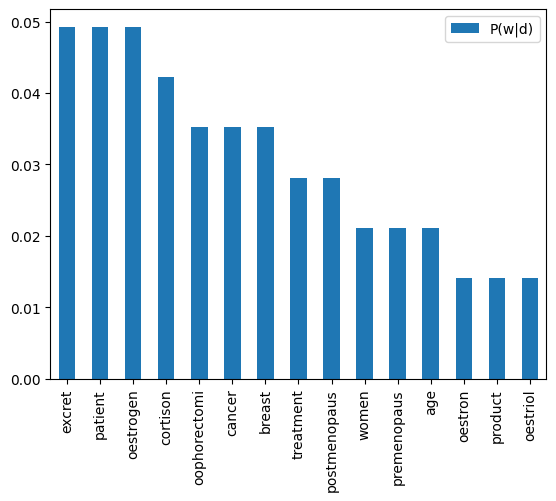





In [ ]:
import pandas as pd

key_to_test = 150  # se puede cambiar
if key_to_test in P_w_d_docs or np.int64(key_to_test) in P_w_d_docs:
    doc_df = pd.DataFrame.from_dict(
        P_w_d_docs[key_to_test], orient="index", columns=["P(w|d)"]
    )
    doc_df.sort_values(by="P(w|d)", ascending=False).head(15).plot(kind="bar")
else:
    print(f"La clave {key_to_test} NO existe en P_w_d_docs")

**5.4. Paso 3: construir el modelo de relevancia RM1**

El Relevance Model 1 (RM1) define una distribución de probabilidad sobre términos $w$, combinando:

* la probabilidad de que un documento sea relevante $P(d∣q)$,

* la probabilidad del término dado el documento $P(w∣d)$.

La fórmula es:

$$P_{RM1}​(w)=\sum_{d \in D_{k}}​P(w∣d)⋅P(d∣q)$$

Interpretación:



> Un término tendrá alta probabilidad si:

* aparece mucho en documentos con alta $P(d∣q)$,

* y/o está muy presente en varios documentos relevantes.

Al final, normalizamos $P_{RM1}(w)$ para que:

$$\sum ​P_{RM1}​(w)=1$$



#### **Actividad 5.3: Calcular $P_{RM1}(w)$**

In [ ]:
P_RM1 = defaultdict(float)

for doc_prob, doc_idx in zip(P_d_q, ranking):   # p_d_q ~ P(d|q)

    ##COMPLETAR
    P_w_d = P_w_d_docs[doc_idx]
    for term, prob in P_w_d.items():
        P_RM1[term] += doc_prob * prob

# Normalización
total = sum(P_RM1.values())
P_RM1 = {term: prob / total for term, prob in P_RM1.items()}

El resultado esperado es un diccionario de palabras con sus probabilidades:

In [ ]:
word = "cancer"  # se puede cambiar

if word in P_RM1:
    df = pd.DataFrame([[word, P_RM1[word]]], columns=["word", "P_RM1(w)"])
    display(df)
else:
    print(f"La clave '{word}' NO existe en P_RM1")

**5.5 Paso 4: modelo de la consulta original $P_Q (w)$**

La consulta original $q$ contiene unos pocos términos (por ejemplo, “breast cancer therapy”).

Tomamos:

* $tf(w,q)$ = número de veces que $w$ aparece en la consulta.

* $∣q∣$ = longitud de la consulta (número total de términos).

Definimos:

$$P_{Q}(w)= \frac{tf(w,q)}{∣q∣}$$
	​

Puesto que en el paso 5 se realizará una combinación de modelos, resulta necesario que **ambos modelos estén definidos sobre el mismo conjunto de términos, es decir, sobre el mismo espacio de vocabulario.**

Esto significa:

* $P_Q(w)$ debe contemplar todos los términos que aparezcan en $P_{RM1}(w)$,
* incluso aunque esos términos no formen parte de la consulta original,
* asignando probabilidad $P_{Q}(w)=0$ cuando el término no aparece en la consulta.


In [ ]:
from collections import Counter

q_count = Counter(q_tokens)
q_len = len(q_tokens)

P_Q = {term: 0.0 for term in P_RM1.keys()}
for term, count in q_count.items():
    P_Q[term] = count / q_len

**5.6 Paso 5: mezclar RM1 con la consulta** (da lugar a RM3)

RM1 por sí solo podría alejarse demasiado de la intención original del usuario (*query drift*).

RM3 soluciona esto reintroduciendo explícitamente los términos originales de la consulta mediante la mezcla:

$$P_{RM3}​(w)=(1−λ)⋅P_{Q}​(w)+λ⋅P_{RM1}​(w)$$

* Si λ es alto → damos más peso a los términos descubiertos en documentos.
* Si λ es bajo → damos más peso a la consulta original.

Típicamente, se escoge algo como λ=0.5 o λ=0.6.

In [ ]:
lambda_ = 0.5  # puedes tunearlo
P_RM3 = {w: (1 - lambda_) * P_Q[w] + lambda_ * P_RM1[w] for w in P_RM1}

## **SECCIÓN 6: Construcción de la nueva consulta expandida**

No utilizaremos todos los términos del vocabulario.
Normalmente se hace:

1. Ordenar términos $w$ según $P_{RM3}(w)$ de mayor a menor.

2. Filtrar:


    * stopwords,
    * términos demasiado cortos,
    * términos muy raros o no informativos.

Tomar los $m$ mejores términos como candidatos de expansión:
por ejemplo, $m=20, 30, 40$.

La consulta expandida será:

* los términos originales (con su peso en $P_Q$)

* más los términos de expansión (con su peso en $P_{RM3}$).

A continuación comenzaremos con código sin filtrado.

In [ ]:
# Ordenar términos por peso
sorted_terms = sorted(P_RM3.items(), key=lambda x: x[1], reverse=True)

# Parámetro m (términos de expansión)
m = 50
expansion_terms = [w for w, _ in sorted_terms[:m]]
print("Términos de expansión seleccionados:", expansion_terms)

A continuación realizaremos el filtrado intermedio. Se observa como para un parámetro $m=50$, los términos no coinciden.

In [ ]:
stop_words = set(stopwords.words("english"))  # cambiar idioma si procede

# Ordenar por probabilidad
sorted_terms = sorted(P_RM3.items(), key=lambda x: x[1], reverse=True)


# Función de filtrado
def is_valid_term(w, min_len=3):
    # Largo mínimo
    if len(w) < min_len:
        return False
    # Solo letras (evita números, tokens raros, etc.)
    if not w.isalpha():
        return False
    # Stopwords
    if w.lower() in stop_words:
        return False
    if P_RM1[w] < 1e-6:
        return False
    return True


# Aplicar filtrado antes de seleccionar expansión
filtered_terms = [(w, score) for w, score in sorted_terms if is_valid_term(w)]

# Seleccionar m términos para expansión
m = 50
expansion_terms = [w for w, _ in filtered_terms[:m]]

print("Términos candidatos de expansión:", expansion_terms)

#### **Actividad 6.1: Construir consulta expandida**

In [ ]:
expanded_query_tokens = set(q_tokens + expansion_terms)

## **SECCIÓN 7: Segunda búsqueda y evaluación**

Vamos a ejecutar BM25 nuevamente pero esta vez con la consulta expandida.

In [ ]:
expanded_scores = bm25.get_scores(expanded_query_tokens)
print(expanded_scores)

Finalmente podemos comparar los resultados entre la simple consulta y la consulta expandida.

In [ ]:
import numpy as np


def show_results(scores, docs, title, top_k=10, preview_len=150):
    print(f"\n=== {title} ===")
    ranked_idx = np.argsort(scores)[::-1][:top_k]

    for rank, idx in enumerate(ranked_idx, start=1):
        snippet = str(docs[idx]).replace("\n", " ")[:preview_len]
        print(f"{rank:02d}. Doc {idx} | Score={scores[idx]:.4f} | {snippet}...")


show_results(scores, docs_raw, "Ranking original")
show_results(expanded_scores, docs_raw, "Ranking con RM3")

Es **totalmente normal, y además esperable, que los valores del ranking con RM3 sean mucho mayores** que los obtenidos inicialmente con BM25.

En la expansión con RM3 ya no estás usando únicamente BM25, sino que:

* Transformas la consulta y la haces más larga (con varios términos añadidos)

* Repites términos ponderados por relevancia, lo que influye en BM25

* La nueva consulta produce puntajes acumulados mayores porque BM25 suma contribuciones por cada término de la consulta

**¿Cuándo sería preocupante?**

Solo sería un problema si observaras:

* ❌ todos los documentos reciben valores muy parecidos (perdería poder discriminativo)
* ❌ el ranking se llena de documentos irrelevantes (query drift)
* ❌ los scores crecen hacia infinito iterativamente

A continuación se muestra el resultado mostrado las diferencias entre realizarlo con y sin expansión.

In [ ]:
orig = set(np.argsort(scores)[::-1][:10])
new = set(np.argsort(expanded_scores)[::-1][:10])

print("\nDocs nuevos aportados por RM3:", new - orig)
print("Docs perdidos tras RM3:", orig - new)

## **SECCIÓN 8: Análisis final**

Preguntas de reflexión:

1. ¿Mejoran los resultados según tu criterio?

2. ¿Aparecen documentos claramente más relevantes?

3. ¿Existen casos de query drift?
Existe caso de query drift, puesto que documentos que originalmente eran muy relevantes como el 44

4. ¿Cómo afecta modificar k, m y λ?